<a href="https://colab.research.google.com/github/Odeyiany2/ACCESS-6.0-Skills-Acquisition-Program-Data-Science/blob/main/solution/Solution_for_Week_1_to_Week_3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the solution for week 1 to week 3 assignments. Use it to recheck what you have done and see where you made mistakes. This is just to serve as a guide.

## **Solution to Week One Assignment**

### **Week 1 Session 2 (Python Basics)**

Write a function that takes a list of transaction amounts and prints:
- total sum of transactions
- average amount :
- number of transactions

In [ ]:
#function that takes a list of transaction amounts and prints -> sum, average and number of transactions
def transaction_summary(transaction_list):
  """
  This function takes a list of transaction amounts and prints:
  - total sum of transactions
  - average amount
  - number of transactions
  """
  total_sum = sum(transaction_list)
  average = total_sum / len(transaction_list)
  number_of_transactions = len(transaction_list)

  print(f"Total sum of transactions: {total_sum}")
  print(f"Average amount: {average}")
  print(f"Number of transactions: {number_of_transactions}")

In [ ]:
#testing the function above
transaction_list = [100, 200, 300, 400, 500]
transaction_summary(transaction_list)

Total sum of transactions: 1500
Average amount: 300.0
Number of transactions: 5


In [ ]:
#allowing the user to input his/her transaction list using the input statement
transaction_list = input("Enter transaction amounts separated by spaces: ").split()
transaction_list = [float(x) for x in transaction_list]
transaction_summary(transaction_list)

## **Solution to Week Two Assignment**

### **Week 2 Session 3 (Data Handling and Inspection)**

### **Part 1: Reading & Inspecting Your Dataset (Very Important)**

1. Load your dataset into a pandas DataFrame using pd.read_csv() or the correct method for your file type.

2. Use the following inspection methods and answer the accompanying questions:

   *  `df.head()`  - Question: What are the first 3 things you notice in your dataset?
   * `df.tail()` - Question: Are there any unusual patterns in the last few rows?
   * `df.info()` - Questions: How many rows and columns do you have?, Which columns have missing values?, What are the data types of each column?
   * `df.describe()` - Question: Which numerical column has the highest mean?, Which column has an unusually high maximum or a suspicious minimum?
   
   * `df.columns and df.shape` - Question: List all column names. What is the full size of your dataset?




### **Part 2: Column Selection & Basic Filtering**

Perform the following tasks and paste your code + result:

A. Selecting Columns

Select any two numerical columns and display them.

Select any two categorical columns and display them.

B. Filtering Rows

- Filter rows using one condition — for example:

   Income > 50,000

   Age < 25

   Rating == 5
  (Choose any condition that fits the dataset.)

- Filter rows using two conditions (using & or |).
  Example: customers who are Female and spent above 10,000.

  Use .loc[] to:

    - Filter a set of rows

    - Display only 2–3 selected columns for those rows.

C. Using .iloc[]

- Use .iloc[] to display:

- The first 5 rows and first 3 columns

- Rows 10–20 and columns 2–4


### **Part 3: Grouping & Aggregation (Critical Skill)**

- Use groupby() on one categorical column in your dataset.

- Choose any questions that make sense for your data:

A. Aggregation (one metric)

- Calculate the total of a numerical column for each category.
Example: Total amount spent per category.

B. Aggregation (multiple metrics)

- Use .agg() to calculate two or three metrics such as:

     - sum

     - mean

     - max

     - count

- Example:
“For each product category, calculate the total, average, and maximum transaction amount.”

C. Interpretation (very important)
  - In 3–4 sentences, write your interpretation of the results.
(What does this tell you about the dataset?)


In [ ]:
from google.colab import drive
import pandas as pd

#getting the dataset
drive.mount('/content/drive')

Mounted at /content/drive


#### **Part 1**

In [ ]:
#reading the dataset
df = pd.read_csv('/content/drive/MyDrive/Warehouse_and_Retail_Sales.csv')
df.head() # Display the first few rows

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


Question: What are the first three things you notice about the dataset?

Answer: The dataset contains a list of items sold. It has the year, the month and the details of the item like its description and the amount of sales that was made for that item.

In [ ]:
#getting the last few rows
df.tail()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
307640,2020,9,LEGENDS LTD,99753,DUTCHESS DE BOURGOGNE NR - 750ML,BEER,0.00,0.0,5.00
307641,2020,9,ANHEUSER BUSCH INC,9997,HOEGAARDEN 4/6NR - 12OZ,BEER,66.12,37.0,240.75
307642,2020,9,COASTAL BREWING COMPANY LLC,99970,DOMINION OAK BARREL STOUT 4/6 NR - 12OZ,BEER,2.25,0.0,0.00
307643,2020,9,BOSTON BEER CORPORATION,99990,SAM ADAMS SUMMER VARIETY 12PK NR,BEER,20.50,0.0,0.00
307644,2020,9,NaN,WC,WINE CREDIT,REF,0.00,0.0,-70.00


Question: Are there any unusual patterns in the last few rows?

Answer: Yes there is an unusual pattern, the `SUPPLIER` column has a missing value, the `ITEM CODE` column has a mix of number code and text code

In [ ]:
#getting summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307478 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307644 non-null  object 
 6   RETAIL SALES      307642 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB


In [ ]:
# you can also use this code to clearly check the columns that have missing values
df.columns[df.isna().any()]

Index(['SUPPLIER', 'ITEM TYPE', 'RETAIL SALES'], dtype='object')

In [ ]:
#code 2 for checking columns with missing values
df.isna().sum()

,0
YEAR,0
MONTH,0
SUPPLIER,167
ITEM CODE,0
ITEM DESCRIPTION,0
ITEM TYPE,1
RETAIL SALES,3
RETAIL TRANSFERS,0
WAREHOUSE SALES,0


In [ ]:
#code 3 for checking columns with missing values
for col in df.columns:
  if df[col].isna().sum() > 0:
    print(f"{col}: {df[col].isna().sum()}")

SUPPLIER: 167
ITEM TYPE: 1
RETAIL SALES: 3


In [ ]:
#you can also use this code to clearly check the number of rows and columns in the dataset
df.shape

(307645, 9)

Questions:
- How many rows and columns do you have? - we have 307645 rows and 9 columns
- Which columns have missing values? - The `SUPPLIER`, `ITEM TYPE` and the `RETAIL SALES` have missing values
- What are the data types of each column? - It is a mix of int64, float64 and object datatype.



In [ ]:
#checking the summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,307645.0,2018.438525,1.083061,2017.00,2017.0,2019.00,2019.0000,2020.00
MONTH,307645.0,6.423862,3.461812,1.00,3.0,7.00,9.0000,12.00
RETAIL SALES,307642.0,7.024071,30.986238,-6.49,0.0,0.32,3.2675,2739.00
RETAIL TRANSFERS,307645.0,6.936465,30.237195,-38.49,0.0,0.00,3.0000,1990.83
WAREHOUSE SALES,307645.0,25.294597,249.916798,-7800.00,0.0,1.00,5.0000,18317.00


Question:
- Which numerical column has the highest mean?

Ans: Not considering the `YEAR` and `MONTH` columns because they are not important, the `WAREHOUSE SALES` column has the highest mean.

- Which column has an unusually high maximum or a suspicious minimum?

Ans: Still not considering the `YEAR` and `MONTH` columns because they are not important, the `WAREHOUSE SALES` has an unusually high maximum and the it also has a suspicious minimum.

In [ ]:
# Question: List all column names. What is the full size of your dataset?
print(f"Column names: {df.columns.to_list()}")
print(f"Full size of dataset (rows and columns): {df.shape}")

Column names: ['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION', 'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']
Full size of dataset (rows and columns): (307645, 9)


#### **Part 2**

In [ ]:
#selecting any two numerical column
df[['WAREHOUSE SALES', 'RETAIL SALES']].head()

,WAREHOUSE SALES,RETAIL SALES
0,2.0,0.00
1,4.0,0.00
2,1.0,0.00
3,1.0,0.00
4,0.0,0.82


In [ ]:
#selecting any two categorical column
df[['ITEM TYPE', 'SUPPLIER']].head()

,ITEM TYPE,SUPPLIER
0,WINE,REPUBLIC NATIONAL DISTRIBUTING CO
1,WINE,PWSWN INC
2,BEER,RELIABLE CHURCHILL LLLP
3,WINE,LANTERNA DISTRIBUTORS INC
4,WINE,DIONYSOS IMPORTS INC


In [ ]:
#filtering the rows using a condition of my choice
df[df['RETAIL SALES'] > 1000].head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
12941,2020,7,NaN,2,ICE,NON-ALCOHOL,2739.00,0.00,0.00
13281,2020,7,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,1174.00,1041.00,18317.00
19778,2020,7,FIFTH GENERATION INC,53929,TITO'S HANDMADE VODKA - 1.75L,LIQUOR,1482.17,1507.00,22.00
31165,2020,3,FIFTH GENERATION INC,53929,TITO'S HANDMADE VODKA - 1.75L,LIQUOR,1816.49,1990.83,10.00
36694,2017,6,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,1249.00,1160.00,13723.71


In [ ]:
#filtering the rows using two conditions - using the AND operator - both conditions will have to be true
df[(df['RETAIL SALES'] > 1000) & (df['ITEM TYPE'] == 'BEER')].head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
13281,2020,7,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,1174.00,1041.00,18317.00
36694,2017,6,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,1249.00,1160.00,13723.71
48174,2017,6,CROWN IMPORTS,96741,CORONA EXTRA 4/6 NR - 12OZ,BEER,1138.36,1162.96,7210.92
50240,2017,7,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,1364.00,1186.00,8521.92
61203,2017,7,CROWN IMPORTS,96741,CORONA EXTRA 4/6 NR - 12OZ,BEER,1005.20,991.00,7057.58


In [ ]:
#filtering the rows using two conditions - using the OR operator - at least one condition has to be true
df[(df['RETAIL SALES'] > 1000) | (df['ITEM TYPE'] == 'FOOD')].head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
12941,2020,7,NaN,2,ICE,NON-ALCOHOL,2739.00,0.00,0.00
13281,2020,7,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,1174.00,1041.00,18317.00
19778,2020,7,FIFTH GENERATION INC,53929,TITO'S HANDMADE VODKA - 1.75L,LIQUOR,1482.17,1507.00,22.00
31165,2020,3,FIFTH GENERATION INC,53929,TITO'S HANDMADE VODKA - 1.75L,LIQUOR,1816.49,1990.83,10.00
36694,2017,6,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,1249.00,1160.00,13723.71


In [ ]:
#using .loc to filter a set of rows: this would select only rows with sales greater than 1,000 and
#then select the item type and supplier columns of those rows
df.loc[df['RETAIL SALES'] > 1000, ['ITEM TYPE', 'SUPPLIER']].head()


,ITEM TYPE,SUPPLIER
12941,NON-ALCOHOL,NaN
13281,BEER,CROWN IMPORTS
19778,LIQUOR,FIFTH GENERATION INC
31165,LIQUOR,FIFTH GENERATION INC
36694,BEER,CROWN IMPORTS


In [ ]:
#using iloc to display the first 5 rows and first 3 columns
df.iloc[:5, :3]

,YEAR,MONTH,SUPPLIER
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO
1,2020,1,PWSWN INC
2,2020,1,RELIABLE CHURCHILL LLLP
3,2020,1,LANTERNA DISTRIBUTORS INC
4,2020,1,DIONYSOS IMPORTS INC


In [ ]:
#using iloc to display rows 10-20 and columns 2-4
df.iloc[10:21, 2:5]

,SUPPLIER,ITEM CODE,ITEM DESCRIPTION
10,HEAVEN HILL DISTILLERIES INC,10120,J W DANT BOURBON 100P - 1.75L
11,BACCHUS IMPORTERS LTD,10123,NOTEWORTHY SMALL BATCH BOURBON - 750ML
12,BACCHUS IMPORTERS LTD,10124,NOTEWORTHY SMALL BATCH RYE 750ML
13,BACCHUS IMPORTERS LTD,10125,NOTEWORTHY SMALL BATCH HONEY BBN 750
14,MONSIEUR TOUTON SELECTION,101346,ALSACE WILLIAM GEW - 750ML
15,"THE COUNTRY VINTNER, LLC DBA WINEBOW",101486,POLIZIANO ROSSO MONTEPUL - 750ML
16,"THE COUNTRY VINTNER, LLC DBA WINEBOW",101532,HATSUMAGO SAKE JUN MAI SHU - 720ML
17,ROYAL WINE CORP,101664,RAMON CORDOVA RIOJA - 750ML
18,REPUBLIC NATIONAL DISTRIBUTING CO,101702,MANISCHEWITZ CREAM RED CONCORD - 1.5L
19,ROYAL WINE CORP,101753,BARKAN CLASSIC PET SYR - 750ML


#### **Part 3**

In [ ]:
#using groupby on one categorical column in the dataset
df.groupby('ITEM TYPE').count()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
ITEM TYPE,,,,,,,,
BEER,42413,42413,42413,42413,42413,42413,42413,42413
DUNNAGE,95,95,72,95,95,95,95,95
KEGS,10146,10146,10146,10146,10146,10146,10146,10146
LIQUOR,64910,64910,64910,64910,64910,64910,64910,64910
NON-ALCOHOL,1908,1908,1899,1908,1908,1905,1908,1908
REF,127,127,79,127,127,127,127,127
STR_SUPPLIES,405,405,318,405,405,405,405,405
WINE,187640,187640,187640,187640,187640,187640,187640,187640


In [ ]:
#aggregation one metric - Calculate the total of a numerical column for each category
df.groupby('ITEM TYPE')['RETAIL SALES'].sum()

,RETAIL SALES
ITEM TYPE,
BEER,574220.53
DUNNAGE,0.00
KEGS,0.00
LIQUOR,802691.43
NON-ALCOHOL,34084.31
REF,663.63
STR_SUPPLIES,2740.88
WINE,746498.59


In [ ]:
#aggregation multiple metrics
df.groupby('ITEM TYPE').agg({'RETAIL SALES': ['sum', 'mean', 'max', 'count']})

RETAIL SALES                            
                      sum       mean      max   count
ITEM TYPE                                            
BEER            574220.53  13.538786  1494.00   42413
DUNNAGE              0.00   0.000000     0.00      95
KEGS                 0.00   0.000000     0.00   10146
LIQUOR          802691.43  12.366221  1816.49   64910
NON-ALCOHOL      34084.31  17.892026  2739.00    1905
REF                663.63   5.225433    36.00     127
STR_SUPPLIES      2740.88   6.767605   368.64     405
WINE            746498.59   3.978355   813.84  187640

The aggregation with multiple metrics tells us that the item LIQUOR has the highest total sum but WINE is bought so many times has it has the highest count/frequency. Majority of the customers buy wine but since Wine is cheaper, LIQUOR has a higher total sale regardless of quantity sold.

### **Week 2 Session 4 - (Data Cleaning)**

- Handle missing values and duplicates.


- Create at least two new derived columns (e.g., performance ratios or total campaign success).


- Save the cleaned dataset as a new CSV and commit to GitHub.

In [ ]:
#inspection of the retail sales and warehouse sales column to know tha values there
df[['RETAIL SALES', 'WAREHOUSE SALES']].head()

,RETAIL SALES,WAREHOUSE SALES
0,0.00,2.0
1,0.00,4.0
2,0.00,1.0
3,0.00,1.0
4,0.82,0.0


Some values in the columns are negative and some are completely zero. What does this mean?

Going back to read the dataset documentation (data card) and applying basic business and accounting knowledge, we can deduce the following:

**Negative sales** values in the Retail_Sales and Warehouse_Sales columns most likely represent returned cases, reversals of previously recorded sales, inventory or accounting adjustments. All of these are in real-world sales and financial datasets. So basically they are not errors by default. Although negative sales with extremely high values can be considered errors.

**Zero values typically indicate:** No sales occurred during that period, product was unavailable or out of stock (stock out), store or license was inactive, seasonal or discontinued items. The zero figure could mean anything but it should be noted that zero in this case is valid information and should not be treated as missing data.


**Please note that not all unusual values are bad data. Some are meaningful business signals.**

In [ ]:
#checking columns with missing values and their datatype
for col in df.columns:
  if df[col].isna().sum() > 0:
    print(f"{col}: {df[col].isna().sum()} - {df[col].dtype}")

SUPPLIER: 167 - object
ITEM TYPE: 1 - object
RETAIL SALES: 3 - float64


In [ ]:
#checking the frequency of values in the SUPPLIER column
df["SUPPLIER"].value_counts()

,count
SUPPLIER,
REPUBLIC NATIONAL DISTRIBUTING CO,20995
LEGENDS LTD,13634
SOUTHERN GLAZERS WINE AND SPIRITS,11720
E & J GALLO WINERY,10816
"THE COUNTRY VINTNER, LLC DBA WINEBOW",10669
...,...
BARREL ONE INC,1
THE DOG BEVERAGE CO INC,1
FIOR DI SOLE LLC,1


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,307645.0,2018.438525,1.083061,2017.00,2017.0,2019.00,2019.0000,2020.00
MONTH,307645.0,6.423862,3.461812,1.00,3.0,7.00,9.0000,12.00
RETAIL SALES,307642.0,7.024071,30.986238,-6.49,0.0,0.32,3.2675,2739.00
RETAIL TRANSFERS,307645.0,6.936465,30.237195,-38.49,0.0,0.00,3.0000,1990.83
WAREHOUSE SALES,307645.0,25.294597,249.916798,-7800.00,0.0,1.00,5.0000,18317.00


Since supplier and Item type are both objects, we can fill the missing values with the frequency. As for the retail sales, we can fill it with the median since there is a possibility of an outlier.


In [ ]:
#filling missing values in objects with frequency and numeric col with median
df["SUPPLIER"] = df["SUPPLIER"].fillna(df["SUPPLIER"].mode()[0])
df["ITEM TYPE"] = df["ITEM TYPE"].fillna(df["ITEM TYPE"].mode()[0])
df["RETAIL SALES"] = df["RETAIL SALES"].fillna(df["RETAIL SALES"].median())

In [ ]:
#checking if we have no missing values
for col in df.columns:
  if df[col].isna().sum() > 0:
    print(f"{col}: {df[col].isna().sum()} - {df[col].dtype}")
  else:
    print(f"{col} has no missing values")

YEAR has no missing values
MONTH has no missing values
SUPPLIER has no missing values
ITEM CODE has no missing values
ITEM DESCRIPTION has no missing values
ITEM TYPE has no missing values
RETAIL SALES has no missing values
RETAIL TRANSFERS has no missing values
WAREHOUSE SALES has no missing values


In [ ]:
#creating new features based on what we have in the dataset
df['TOTAL SALES'] = df['WAREHOUSE SALES'] + df['RETAIL SALES'] # total sales

#absolute value of total sales -> this will help identify high-activity products or locations even when returns are involved
df["ABS_TOTAL_SALES"] = df["TOTAL SALES"].abs()


#sales direction
df["SALES_DIRECTION"] = df["TOTAL SALES"].apply(
    lambda x: "Positive Sales" if x > 0 else ("No Activity" if x == 0 else "Returns/Adjustment")
)

#creating a new months column with actual name based on the original MONTH column
mapping_months = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

df["MONTH_NAME"] = df["MONTH"].map(mapping_months)



df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,TOTAL SALES,ABS_TOTAL_SALES,RETAIL_WAREHOUSE_RATIO,SALES_DIRECTION,MONTH_NAME
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0,2.00,2.00,0.0,Positive Sales,January
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0,4.00,4.00,0.0,Positive Sales,January
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0,1.00,1.00,0.0,Positive Sales,January
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0,1.00,1.00,0.0,Positive Sales,January
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0,0.82,0.82,inf,Positive Sales,January


In [ ]:
df['SALES_DIRECTION'].value_counts()

,count
SALES_DIRECTION,
Positive Sales,303786
No Activity,3129
Returns/Adjustment,730


In [ ]:
#save the cleaned dataset to my drive
df.to_csv('/content/drive/MyDrive/cleaned_warehouse_retail_sales_dataset.csv', index=False)

## **Solution to Week 3 Assignment**

### **Week 3 Session 5 - Exploratory Data Analysis (EDA)**

Study your dataset and perform
- Data overview and inspection
- Univariate analysis
- Bivariate analysis
- Correlation
- Outlier detection in numeric column(s)
- Answer three business questions developed by you.

### PART A - Data Overview & Inspection

1. Display the **first 5 rows** of the dataset.
2. Display the **last 5 rows** of the dataset.
3. Check:

   * Number of rows and columns
   * Column names
   * Data types
4. Use `.describe()` on numerical columns.
5. Answer:

   * Are there values that suggest possible outliers?
   * Which column(s) might contain unusually large values?



### PART B - Univariate Analysis

### Numerical Analysis

1. Select **one numerical column** related to sales or quantity.
2. Create:

   * A histogram
   * A boxplot
3. Write a short explanation:

   * What does the distribution look like?
   * Are there possible outliers?

### Categorical Analysis

1. Select **one categorical column** (e.g. product type, location, or warehouse).
2. Create a bar chart showing frequency.
3. Write a short explanation:

   * Which category appears most often?
   * What could this mean for the business?

### PART C - Bivariate Analysis

1. Choose:

   * One numerical column
   * One categorical column
2. Visualize their relationship (e.g. boxplot or grouped bar chart).
3. Answer:

   * Does spending/sales vary across categories?
   * Which category appears to generate higher values?

### PART D - Outlier Detection

1. Use:

   * `.describe()`
   * A boxplot
2. Identify whether outliers exist.
3. Answer:

   * Why might these outliers exist?
   * Are they likely errors or genuine business events?

### PART E - Correlation Analysis

1. Select **two numerical columns**.
2. Compute their correlation.
3. Answer:

   * Is the correlation weak, moderate, or strong?
   * How could this information be useful in business analysis?

### PART F - Business Questions & Insights

Develop and answer **THREE (3) business questions**, such as:

* Which warehouse/location records the highest sales?
* Are there products with consistently high sales?
* Are there periods with unusually high sales volumes?
* Which product category generates the most sales?
* Which store type performs better?
* Are there seasonal sales patterns?


#### **Part A**

In [ ]:
#getting the cleaned data we got in the last assignment
cleaned_df = pd.read_csv('/content/drive/MyDrive/cleaned_warehouse_retail_sales_dataset.csv')
cleaned_df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,TOTAL SALES,ABS_TOTAL_SALES,RETAIL_WAREHOUSE_RATIO,SALES_DIRECTION,MONTH_NAME
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0,2.00,2.00,0.0,Positive Sales,January
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0,4.00,4.00,0.0,Positive Sales,January
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0,1.00,1.00,0.0,Positive Sales,January
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0,1.00,1.00,0.0,Positive Sales,January
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0,0.82,0.82,inf,Positive Sales,January


In [ ]:
#last 5 rows
cleaned_df.tail()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,TOTAL SALES,ABS_TOTAL_SALES,RETAIL_WAREHOUSE_RATIO,SALES_DIRECTION,MONTH_NAME
307640,2020,9,LEGENDS LTD,99753,DUTCHESS DE BOURGOGNE NR - 750ML,BEER,0.00,0.0,5.00,5.00,5.00,0.000000,Positive Sales,September
307641,2020,9,ANHEUSER BUSCH INC,9997,HOEGAARDEN 4/6NR - 12OZ,BEER,66.12,37.0,240.75,306.87,306.87,0.274642,Positive Sales,September
307642,2020,9,COASTAL BREWING COMPANY LLC,99970,DOMINION OAK BARREL STOUT 4/6 NR - 12OZ,BEER,2.25,0.0,0.00,2.25,2.25,inf,Positive Sales,September
307643,2020,9,BOSTON BEER CORPORATION,99990,SAM ADAMS SUMMER VARIETY 12PK NR,BEER,20.50,0.0,0.00,20.50,20.50,inf,Positive Sales,September
307644,2020,9,REPUBLIC NATIONAL DISTRIBUTING CO,WC,WINE CREDIT,REF,0.00,0.0,-70.00,-70.00,70.00,-0.000000,Returns/Adjustment,September


In [ ]:
#data inspection
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   YEAR                    307645 non-null  int64  
 1   MONTH                   307645 non-null  int64  
 2   SUPPLIER                307645 non-null  object 
 3   ITEM CODE               307645 non-null  object 
 4   ITEM DESCRIPTION        307645 non-null  object 
 5   ITEM TYPE               307645 non-null  object 
 6   RETAIL SALES            307645 non-null  float64
 7   RETAIL TRANSFERS        307645 non-null  float64
 8   WAREHOUSE SALES         307645 non-null  float64
 9   TOTAL SALES             307645 non-null  float64
 10  ABS_TOTAL_SALES         307645 non-null  float64
 11  RETAIL_WAREHOUSE_RATIO  304518 non-null  float64
 12  SALES_DIRECTION         307645 non-null  object 
 13  MONTH_NAME              307645 non-null  object 
dtypes: float64(6), int64

In [ ]:
#statistics summary
cleaned_df.describe().T

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,count,mean,std,min,25%,50%,75%,max
YEAR,307645.0,2018.438525,1.083061,2017.00,2017.0,2019.000000,2019.00,2020.00
MONTH,307645.0,6.423862,3.461812,1.00,3.0,7.000000,9.00,12.00
RETAIL SALES,307645.0,7.024006,30.986094,-6.49,0.0,0.320000,3.26,2739.00
RETAIL TRANSFERS,307645.0,6.936465,30.237195,-38.49,0.0,0.000000,3.00,1990.83
WAREHOUSE SALES,307645.0,25.294597,249.916798,-7800.00,0.0,1.000000,5.00,18317.00
TOTAL SALES,307645.0,32.318603,266.486254,-7800.00,1.0,2.680000,10.50,19491.00
ABS_TOTAL_SALES,307645.0,33.252250,266.371364,0.00,1.0,2.690000,10.54,19491.00
RETAIL_WAREHOUSE_RATIO,304518.0,NaN,NaN,-inf,0.0,0.336228,NaN,inf


The warehouse sales column has unusually high values and also the total sales column. There might be possible outliers in these columns.

#### **Part B**

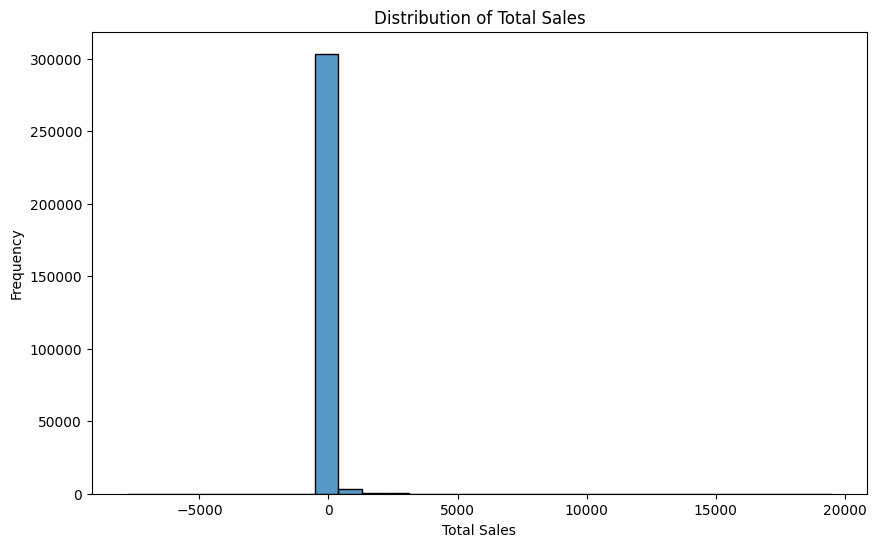

In [ ]:
#performing univariate analysis on a single numeric column of my choice -> Total sales
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['TOTAL SALES'], bins=30, kde=False)
plt.title('Distribution of Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

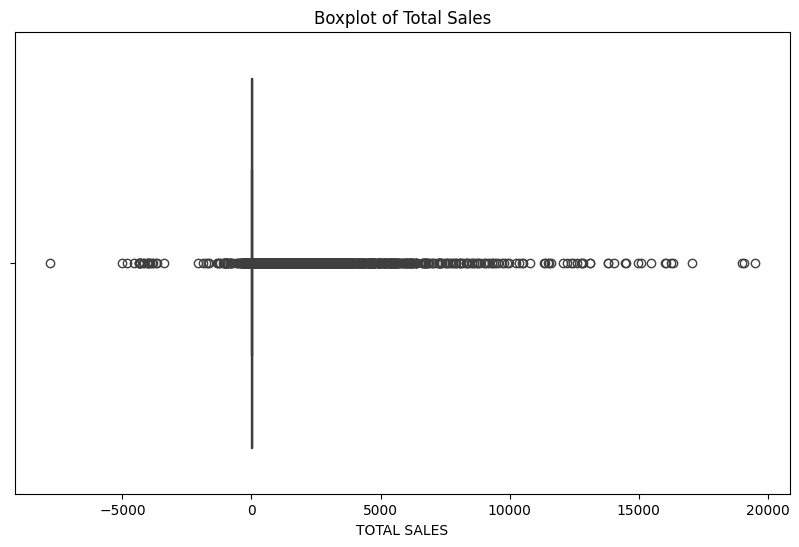

In [ ]:
#performing boxplot analysis on the total sales column
plt.figure(figsize=(10, 6))
sns.boxplot(x=cleaned_df['TOTAL SALES'])
plt.title('Boxplot of Total Sales')
plt.show();

From the above analysis we can conclude that the `TOTAL SALES` column has majority of the value centered in zero and because of that, any figure that proves to be a little high, is considered an outlier. In this case, there would be no need to remove them.

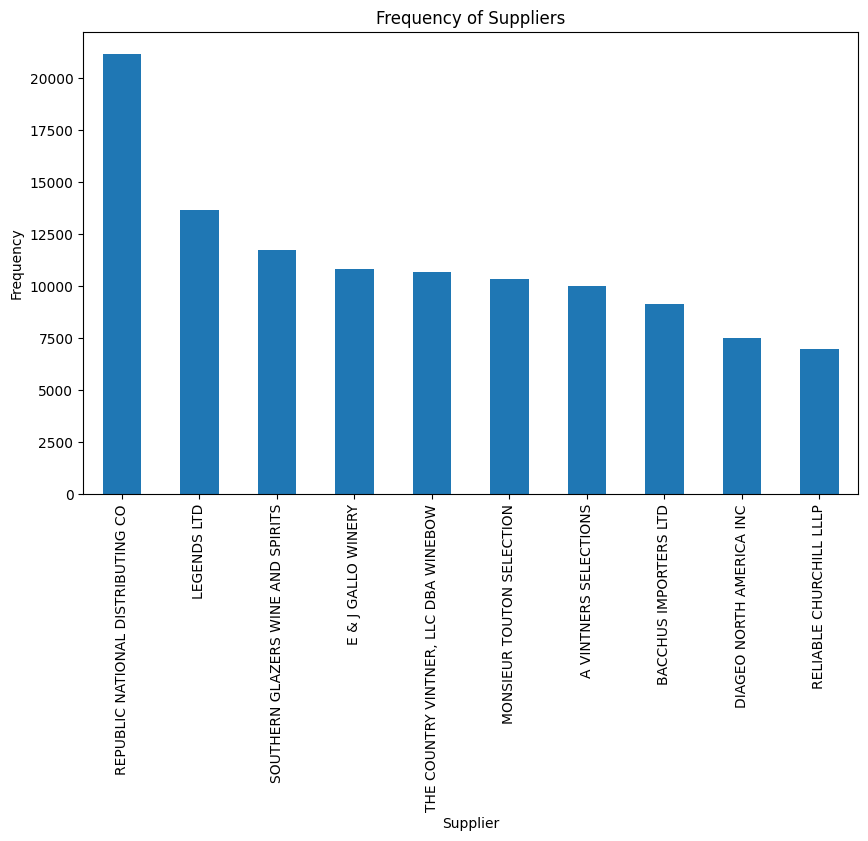

In [ ]:
#frequency of suppliers -> top ten
plt.figure(figsize=(10, 6))
cleaned_df['SUPPLIER'].value_counts().head(10).plot(kind='bar')
plt.title('Frequency of Suppliers')
plt.xlabel('Supplier')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show();

From the above, we can say that the major supplier of the business is Republic National Distributing. This shows that the business purchases more from this supplier and this can likely be attributed to the benefits they enjoy from the supplier such as: trade discounts, on time deliveries and many others.  

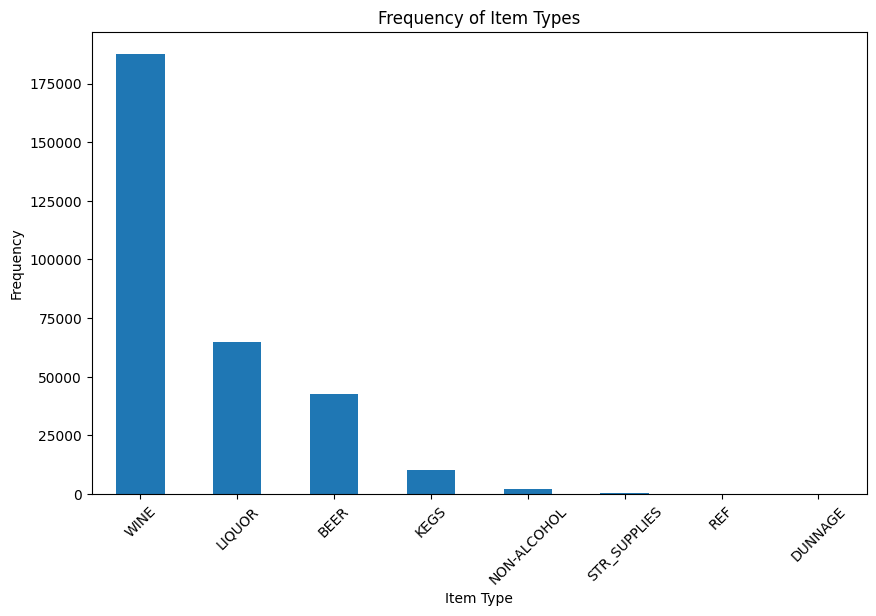

In [ ]:
#categorical analysis -> univariate analysis on the ITEM TYPE column
plt.figure(figsize=(10, 6))
cleaned_df['ITEM TYPE'].value_counts().plot(kind='bar')
plt.title('Frequency of Item Types')
plt.xlabel('Item Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

From the above we can deduce that wine has the highest amount of sales. Meaning that the warehouse and retail store sells a lot of wine but this not not automatically mean that WINE brings the highest total sum to the business. Since WINE has the highest count of sales, it would mean that the business should continually restock on its wine collection so that they don't experience stock out and loose customers.

#### **Part C**

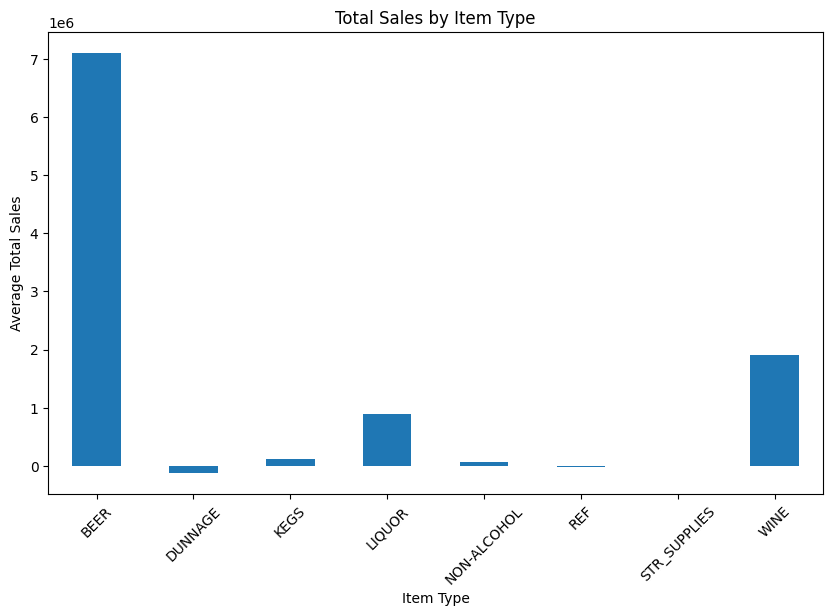

In [ ]:
# bivariate analysis between one numeric column and one categorical column
grouped = cleaned_df.groupby('ITEM TYPE')['TOTAL SALES'].sum()

plt.figure(figsize=(10, 6))
grouped.plot(kind='bar')
plt.title('Total Sales by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Average Total Sales')
plt.xticks(rotation=45)
plt.show();

Sales varies across items. BEER has the highest total sales meaning that even tho the business doesn't have the highest frequency of sales in Beer, they generate the highest amount from their BEER sales.

#### **Part D**

In [ ]:
#identifying outliers in the warehouse sales column
cleaned_df.describe().T

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,count,mean,std,min,25%,50%,75%,max
YEAR,307645.0,2018.438525,1.083061,2017.00,2017.0,2019.000000,2019.00,2020.00
MONTH,307645.0,6.423862,3.461812,1.00,3.0,7.000000,9.00,12.00
RETAIL SALES,307645.0,7.024006,30.986094,-6.49,0.0,0.320000,3.26,2739.00
RETAIL TRANSFERS,307645.0,6.936465,30.237195,-38.49,0.0,0.000000,3.00,1990.83
WAREHOUSE SALES,307645.0,25.294597,249.916798,-7800.00,0.0,1.000000,5.00,18317.00
TOTAL SALES,307645.0,32.318603,266.486254,-7800.00,1.0,2.680000,10.50,19491.00
ABS_TOTAL_SALES,307645.0,33.252250,266.371364,0.00,1.0,2.690000,10.54,19491.00
RETAIL_WAREHOUSE_RATIO,304518.0,NaN,NaN,-inf,0.0,0.336228,NaN,inf


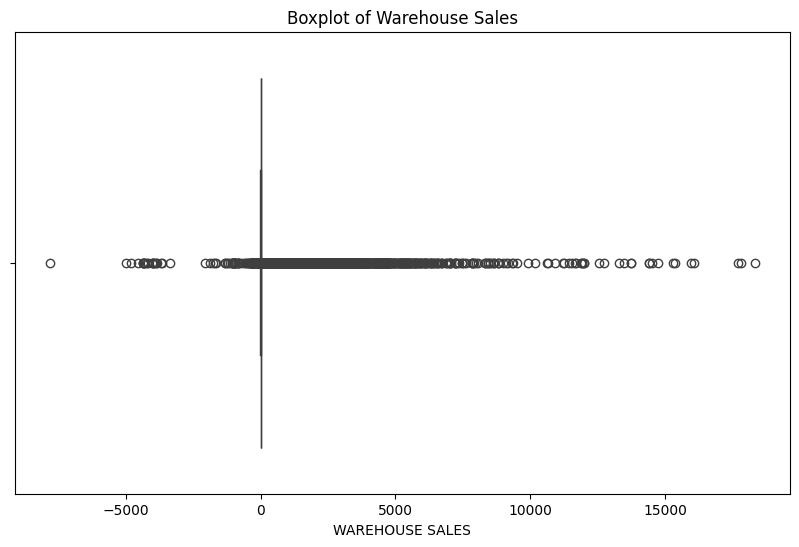

In [ ]:
#plotting a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=cleaned_df['WAREHOUSE SALES'])
plt.title('Boxplot of Warehouse Sales')
plt.show();

In [ ]:
#outlier detection code
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Example usage
outliers = detect_outliers(cleaned_df, 'RETAIL SALES')
print(outliers)

        YEAR  MONTH                        SUPPLIER ITEM CODE  \
22      2020      1              JIM BEAM BRANDS CO     10197   
23      2020      1       STE MICHELLE WINE ESTATES    101974   
40      2020      1                 BACARDI USA INC     10332   
45      2020      1          CASTLE BRANDS USA CORP     10375   
52      2020      1  JACKSON FAMILY ENTERPRISES INC     10413   
...      ...    ...                             ...       ...   
307620  2020      9                   CROWN IMPORTS     99198   
307621  2020      9                   CROWN IMPORTS     99201   
307636  2020      9        SIERRA NEVADA BREWING CO     99708   
307641  2020      9              ANHEUSER BUSCH INC      9997   
307643  2020      9         BOSTON BEER CORPORATION     99990   

                             ITEM DESCRIPTION ITEM TYPE  RETAIL SALES  \
22      KNOB CREEK BOURBON 9YR - 100P - 1.75L    LIQUOR         12.72   
23                  CH ST MICH P/GRIS - 750ML      WINE         11.17   


#### **Part E**

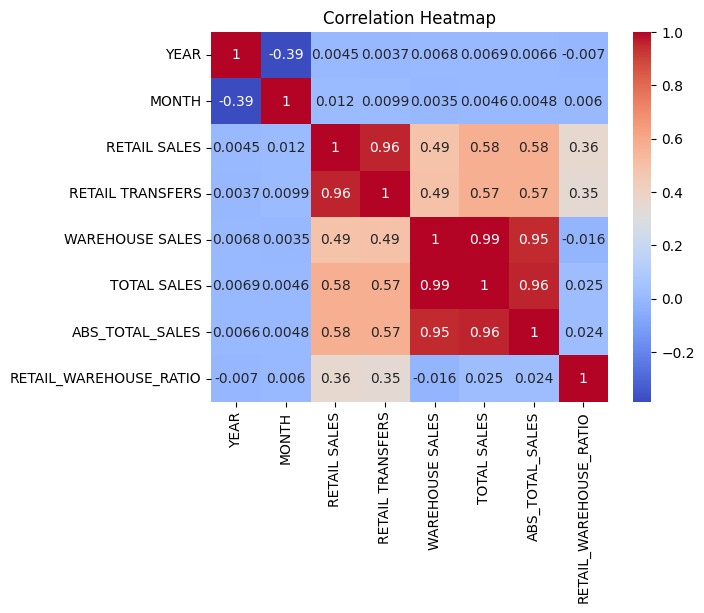

In [ ]:
#correlation between the numeric columns
sns.heatmap(cleaned_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show();

There is a high correlation between total sales and warehouse sales which might be due to the fact that total sales was gotten from the addition of retail and warehouse sales.

We also see a positive but not that high correlation between retail transfers and total sales, total sales and retail sales.

#### **Part F**



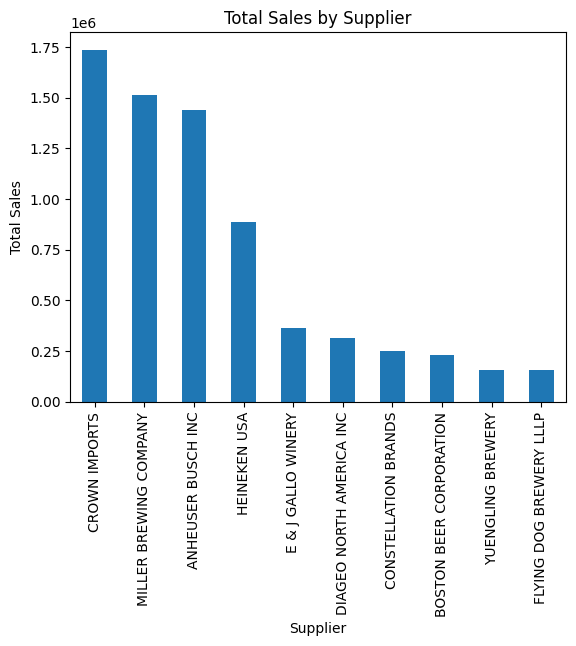

In [ ]:
#Which supplier records the highest sales?
supplier = cleaned_df.groupby('SUPPLIER')['TOTAL SALES'].sum()
#supplier.sort_values(ascending=False)
#plotting the first ten
supplier.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Total Sales by Supplier')
plt.xlabel('Supplier')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show();

The Supplier - CROWN IMPORTS - records the highest sales. So majority of the revenue comes from CROWN IMPORTS sup

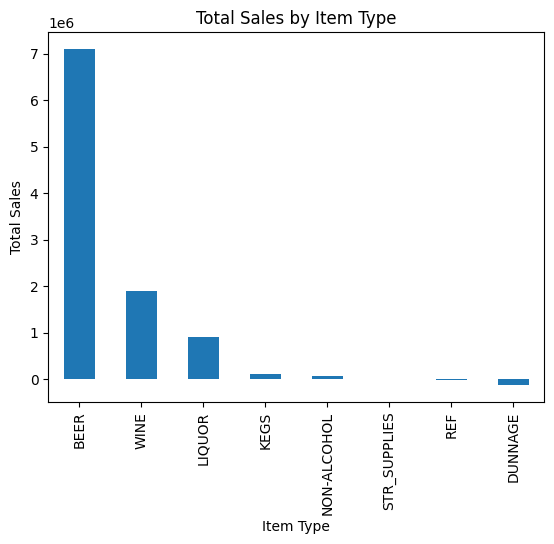

In [ ]:
#* Are there products with consistently high sales?
item_type = cleaned_df.groupby('ITEM TYPE')['TOTAL SALES'].sum()
item_type.sort_values(ascending=False).plot(kind='bar')
plt.title('Total Sales by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show();

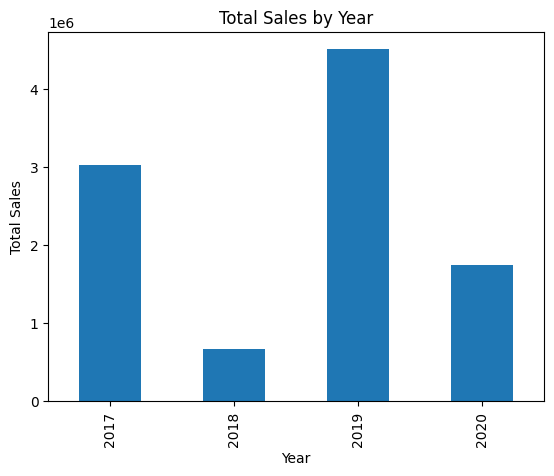

In [ ]:
#* Are there periods with unusually high sales volumes?
cleaned_df.groupby('YEAR')['TOTAL SALES'].sum().plot(kind='bar')
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show();

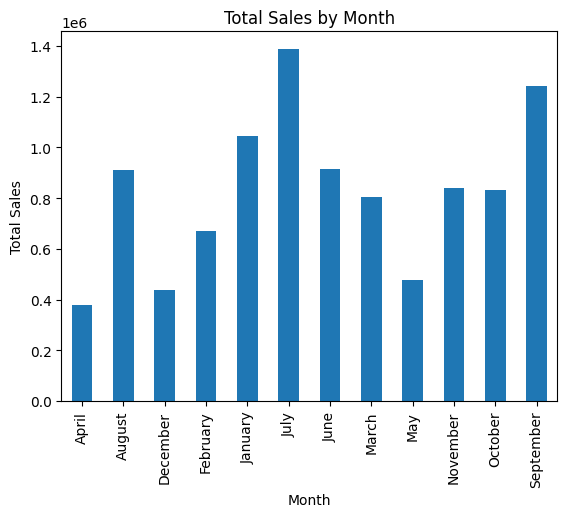

In [ ]:
#* Are there seasonal sales patterns?
cleaned_df.groupby('MONTH_NAME')['TOTAL SALES'].sum().plot(kind='bar')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.xticks(rotation = 90)
plt.ylabel('Total Sales')
plt.show();

July records the highest sales which can be attributed to the fact that it the start of summer period, majority of individuals are on summer breaks and are likely to purchase more which is what the business experiences during this period. They have a high inflow of customers. It can also be highly attributed to the fact that the summer periods are usually really hot and customers are more inclined to get drinks that would be perfect for the summer breaks. The business needs to stock up more during this period so as not to loose customers or experience stock out.

### **Week 3 Session 6 - Further Data Visualization**

Assignment:
Create at least 4 visualizations that communicate a single business story (e.g., trends or performance comparisons).
Continue with the original dataset, or use the [retail dataset](https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset) or
Use the superstore dataset - [Superstore sales](https://www.kaggle.com/datasets/ishanshrivastava28/superstore-sales)

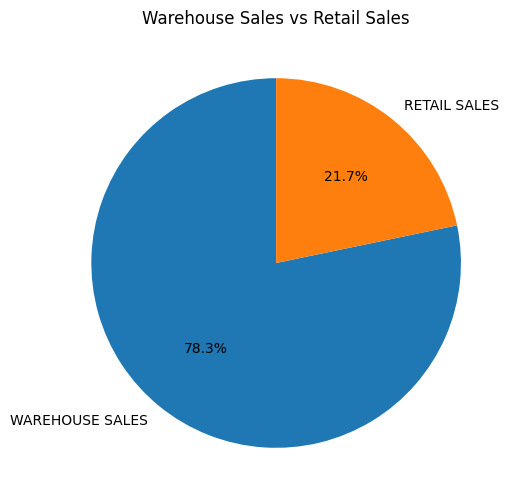

In [ ]:
#further visualization using the warehouse dataset

#piechart for the warehouse sales and retail sales
plt.figure(figsize=(10, 6))
cleaned_df[['WAREHOUSE SALES', 'RETAIL SALES']].sum().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Warehouse Sales vs Retail Sales')
plt.show();

Majority of the revenue of the business comes from its warehose sales. This is why we see from the dataset that when there is no activity in the retail sales, the warehouse sales shows some activity.

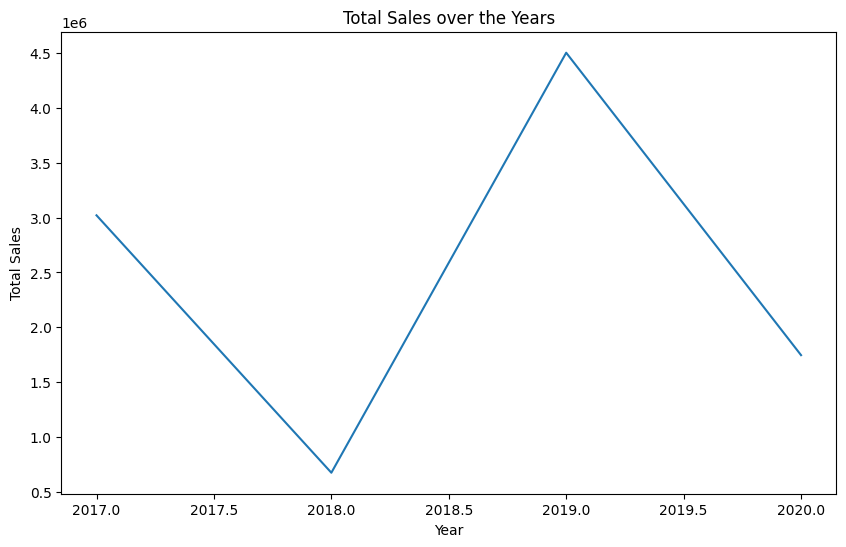

In [ ]:
#line plot for sales over the years
plt.figure(figsize=(10, 6))
cleaned_df.groupby('YEAR')['TOTAL SALES'].sum().plot(kind='line')
plt.title('Total Sales over the Years')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show();

<Figure size 1000x600 with 0 Axes>

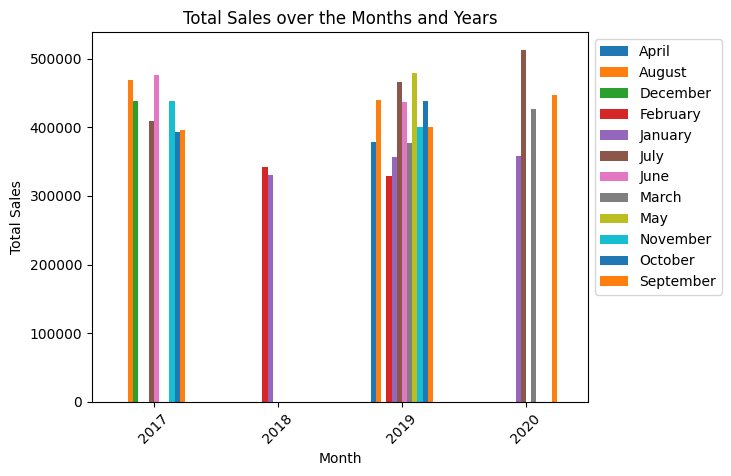

In [ ]:
#bar plot for sales over the months and years
plt.figure(figsize=(10, 6))
cleaned_df.groupby(['YEAR', 'MONTH_NAME'])['TOTAL SALES'].sum().unstack().plot(kind='bar')
plt.title('Total Sales over the Months and Years')
plt.xlabel('Month')
#adjust the legend
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.ylabel('Total Sales')
plt.show();


### **Retail Dataset**

In [ ]:
df_retail = pd.read_csv('/content/drive/MyDrive/retail_sales_dataset.csv')
df_retail.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
#info summary
df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


No missing values but the DAte column has a wrong data type

In [ ]:
#converting the date column to the right data type and then extracting month and year
df_retail['Date'] = pd.to_datetime(df_retail['Date'])
df_retail['Month'] = df_retail['Date'].dt.month
df_retail['Year'] = df_retail['Date'].dt.year

In [ ]:
#check for duplicates
df_retail.duplicated().sum()

np.int64(0)

In [ ]:
df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   int32         
 10  Year              1000 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(5), object(3)
memory usage: 78.3+ KB


In [ ]:
#stats summary
df_retail.describe().T

,count,mean,min,25%,50%,75%,max,std
Transaction ID,1000.0,500.5,1.0,250.75,500.5,750.25,1000.0,288.819436
Date,1000,2023-07-03 00:25:55.200000256,2023-01-01 00:00:00,2023-04-08 00:00:00,2023-06-29 12:00:00,2023-10-04 00:00:00,2024-01-01 00:00:00,NaN
Age,1000.0,41.392,18.0,29.0,42.0,53.0,64.0,13.68143
Quantity,1000.0,2.514,1.0,1.0,3.0,4.0,4.0,1.132734
Price per Unit,1000.0,179.89,25.0,30.0,50.0,300.0,500.0,189.681356
Total Amount,1000.0,456.0,25.0,60.0,135.0,900.0,2000.0,559.997632
Month,1000.0,6.549,1.0,4.0,6.0,10.0,12.0,3.452755
Year,1000.0,2023.002,2023.0,2023.0,2023.0,2023.0,2024.0,0.044699


Text(0, 0.5, 'Total Amount ($)')

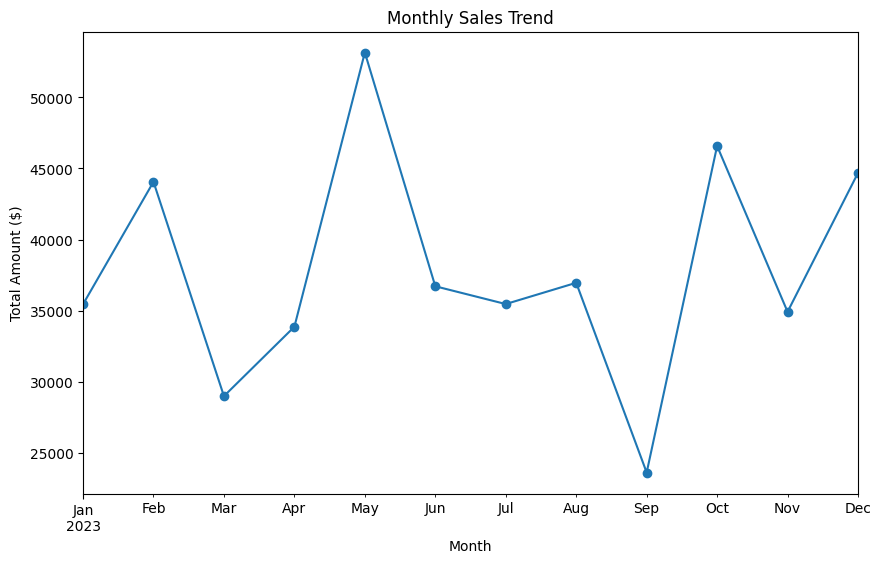

In [ ]:
#monthly sales trend to identify patterns
import matplotlib.pyplot as plt
import seaborn as sns
monthly_sales = df_retail.set_index('Date').resample('ME')['Total Amount'].sum()
#remove the last date for 2024 - because it only has one day of data
# we have max date as 01-01-2024 so not enough data available for Jan 24
monthly_sales = monthly_sales.iloc[:-1]

plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='line', marker = "o")
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Amount ($)')

Peak Performance: Sales reached their highest point in May 2023, crossing $52,000 in total revenue.

Critical Low Point: September 2023 recorded the lowest sales (~$24,000), showing a noticeable post-summer slowdown.

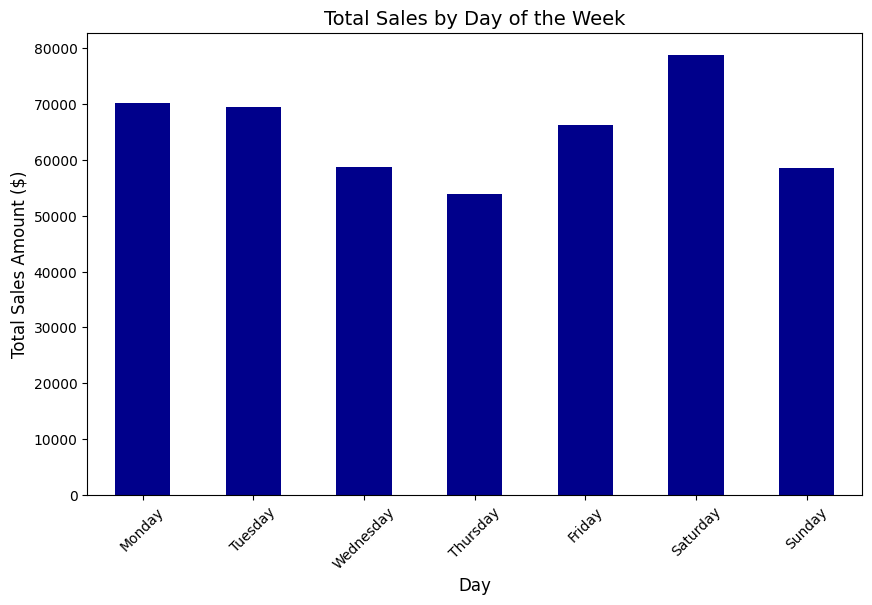

In [ ]:
#weekly sales pattern
#extract day of the week from the date column
df_retail['Day'] = df_retail['Date'].dt.day_name()

#group by Day and sum the sales to see which day is most profitable
daily_sales = df_retail.groupby('Day')['Total Amount'].sum()

#define the correct order for days of the week (Monday to Sunday)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#reindex the series to ensure days appear in the correct order on the chart
daily_sales = daily_sales.reindex(days_order)

# Plotting sales by day
plt.figure(figsize=(10,6))
daily_sales.plot(kind='bar', color='#00008B')
plt.title('Total Sales by Day of the Week', fontsize=14)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Total Sales Amount ($)', fontsize=12)
plt.xticks(rotation=45)
plt.show();

Weekend Dominance: Saturday is the highest performing sales day globally, suggesting customers prefer weekend shopping.
Mid-Week Dip: Sales tend to be lower on Wednesdays and Thursdays.

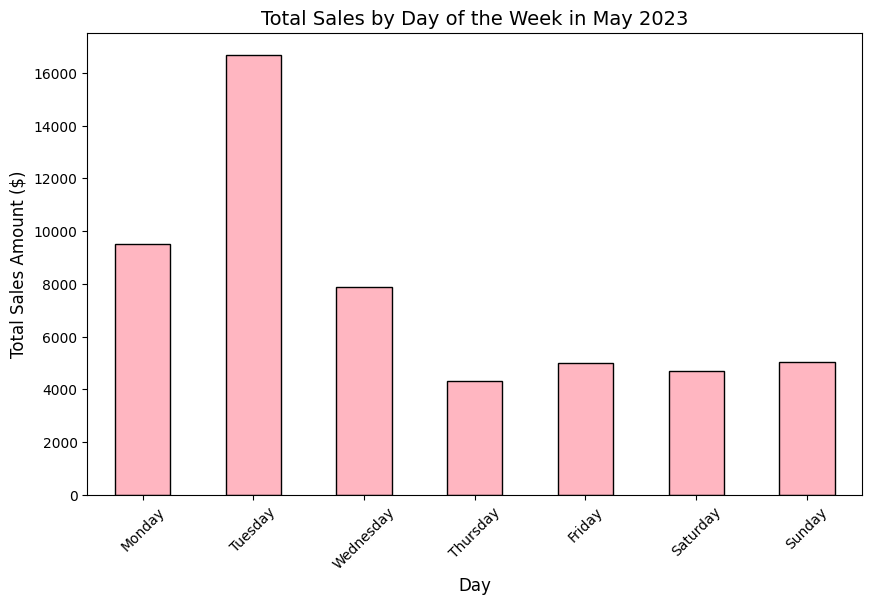

In [ ]:
#deep dive into the month of May since it is the highest performing month in the year 2023
may_data = df_retail[(df_retail["Year"]== 2023) & (df_retail['Month'] == 5)]


#total sales for may daily
may_daily_sales = may_data.groupby('Day')['Total Amount'].sum()

#reindex the series to ensure days appear in the correct order on the chart
may_daily_sales = may_daily_sales.reindex(days_order)

#plot
plt.figure(figsize=(10,6))
may_daily_sales.plot(kind='bar', color='#FFB6C1', edgecolor='black')
plt.title('Total Sales by Day of the Week in May 2023', fontsize=14)
plt.xlabel('Day', fontsize=12)
plt.xticks(rotation=45)
plt.ylabel('Total Sales Amount ($)', fontsize=12)
plt.show();

Unlike how we saw previously that saturday is the highest performing day globally, In may 2023, Tuesday is the highest performing day.
This suggests a specific event, flash sale, or bulk order occurred on Tuesdays in May, driving the monthly peak.

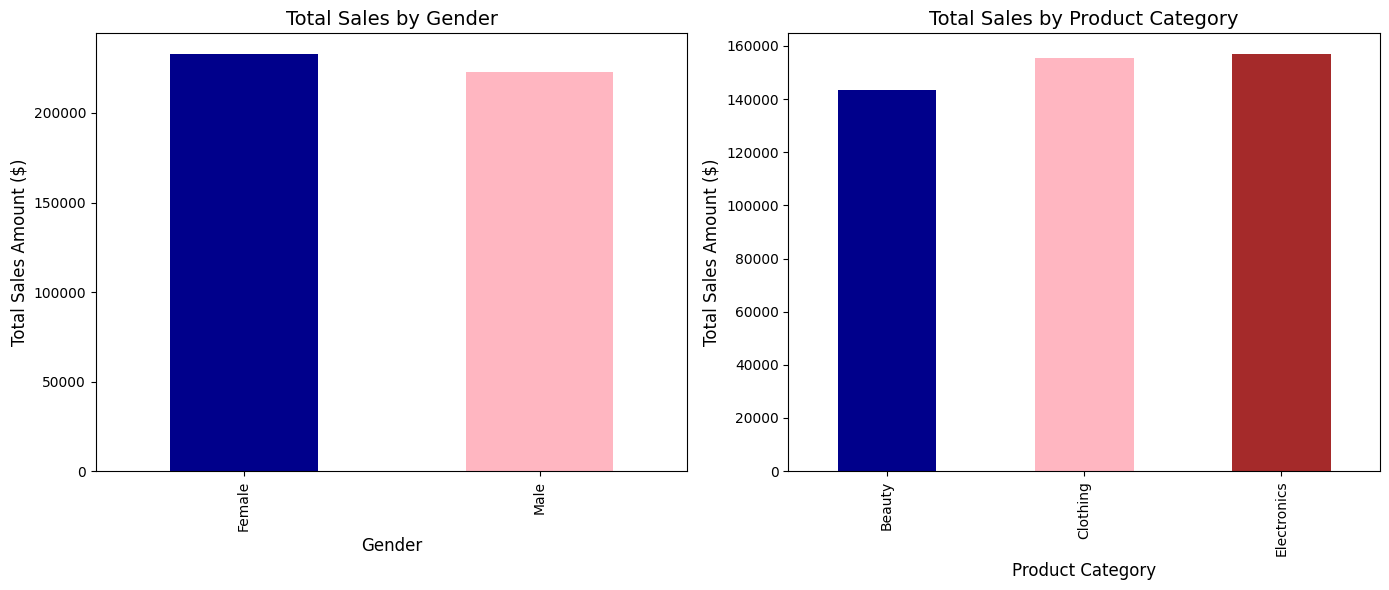

In [ ]:
#total sales by Gender
gender_sales = df_retail.groupby('Gender')['Total Amount'].sum()

#total sales by Product Category
product_sales = df_retail.groupby('Product Category')['Total Amount'].sum()

# Plotting Gender and Category performance side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#chart 1 with different color for both gender
color = ['#00008B', '#FFB6C1']
gender_sales.plot(kind='bar', ax=axes[0], color = color)
axes[0].set_title('Total Sales by Gender', fontsize=14)
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Total Sales Amount ($)', fontsize=12)

#chart 2 with different colors
color = ['#00008B', '#FFB6C1', '#A52A2A']
product_sales.plot(kind='bar', ax=axes[1], color=color)
axes[1].set_title('Total Sales by Product Category', fontsize=14)
axes[1].set_xlabel('Product Category', fontsize=12)
axes[1].set_ylabel('Total Sales Amount ($)', fontsize=12)

plt.tight_layout()
plt.show();


Females generate slightly more revenue than Males, but the difference is not massive. For products, Electronics is the highest-grossing category, followed closely by Clothing and Beauty.

<Figure size 1000x600 with 0 Axes>

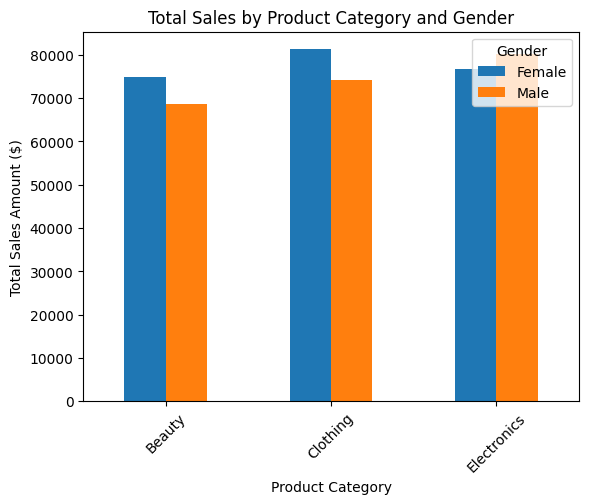

In [ ]:
#purchsing behavior - Do men and women buy different things? This analysis helps target marketing campaigns more effectively.

# Group by Category AND Gender to see the breakdown
category_gender_sales = df_retail.groupby(['Product Category', 'Gender'])['Total Amount'].sum().unstack()

# Plotting the data
plt.figure(figsize=(10, 6))
category_gender_sales.plot(kind='bar')
plt.title('Total Sales by Product Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount ($)')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.show();


Electronics: This is a male-dominated category (Men spend significantly more here).
Beauty & Clothing: These categories see higher engagement from female customers.
Strategy: Marketing for new gadgets should target male demographics, while fashion and skincare campaigns should prioritize female audiences.

/tmp/ipython-input-1425194261.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_sales = df_retail.groupby('Age Group')['Total Amount'].sum()


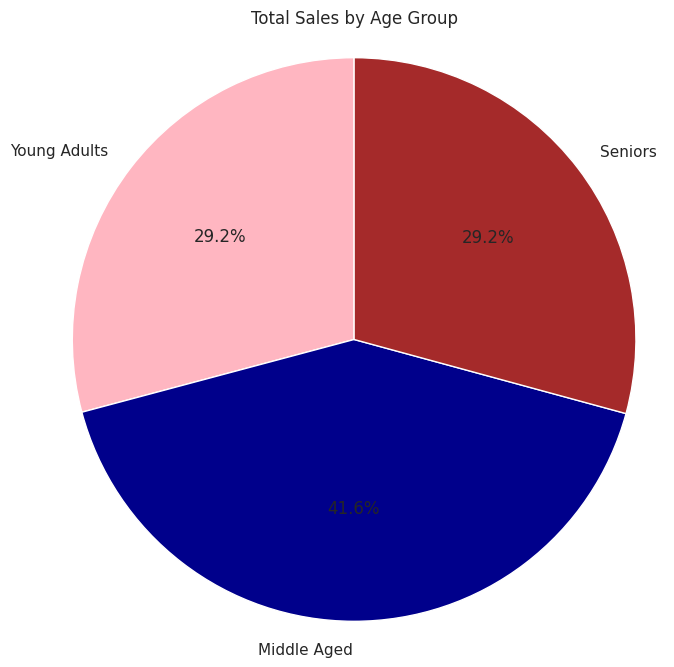

In [ ]:
#sales by age group -
#segment customers into "Young Adults", "Middle Aged", and "Seniors" to understand age related spending habits.

#define bins
bins = [0, 30, 50, 100]
labels = ['Young Adults', 'Middle Aged', 'Seniors']

#create a new column
df_retail['Age Group'] = pd.cut(df_retail['Age'], bins=bins, labels=labels)

#group by age group and sum the sales
age_group_sales = df_retail.groupby('Age Group')['Total Amount'].sum()

#plotting pie chart with seaborn and color - rocket
plt.figure(figsize=(8, 8))
sns.set(style="whitegrid")
plt.pie(age_group_sales, labels=age_group_sales.index, autopct='%1.1f%%', startangle=90, colors=['#FFB6C1', '#00008B', '#A52A2A'])
plt.title('Total Sales by Age Group')
plt.axis('equal')
plt.show();

Core Demographic: The Middle Aged (30-50) group is the largest revenue driver, contributing roughly 41% of total sales.
Targeting: This group likely has the highest disposable income. Loyalty programs should be designed to retain these valuable customers.

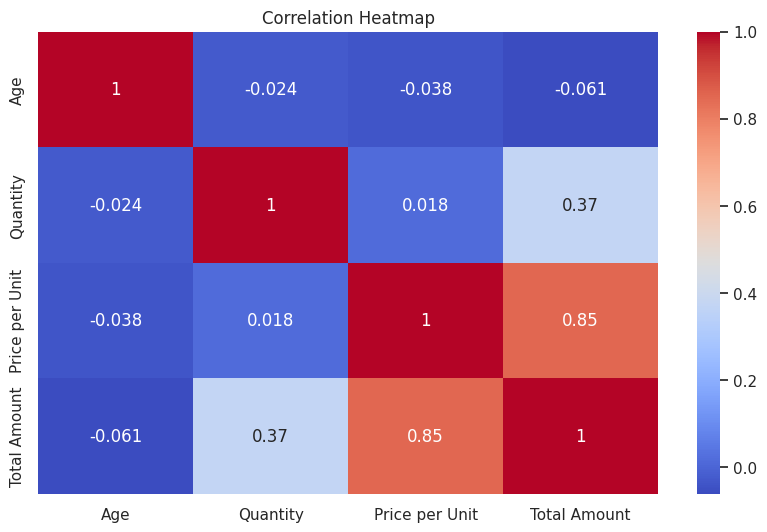

In [ ]:
#🔥 Heatmap: What drives spending?
numeric_cols = ["Age", "Quantity", "Price per Unit", "Total Amount" ]
plt.figure(figsize=(10, 6))
sns.heatmap(df_retail[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show();

### **Superstore Dataset**

In [ ]:
#getting the new dataset for more advanced visualizations
df_super = pd.read_csv('/content/drive/MyDrive/Superstore.csv', encoding='latin1')
df_super.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
#changing the dtype for some of the columns to the apppropriate ones
df_super['Order Date'] = pd.to_datetime(df_super['Order Date'], format='%d-%m-%Y')
df_super['Ship Date'] = pd.to_datetime(df_super['Ship Date'], format='%d-%m-%Y')

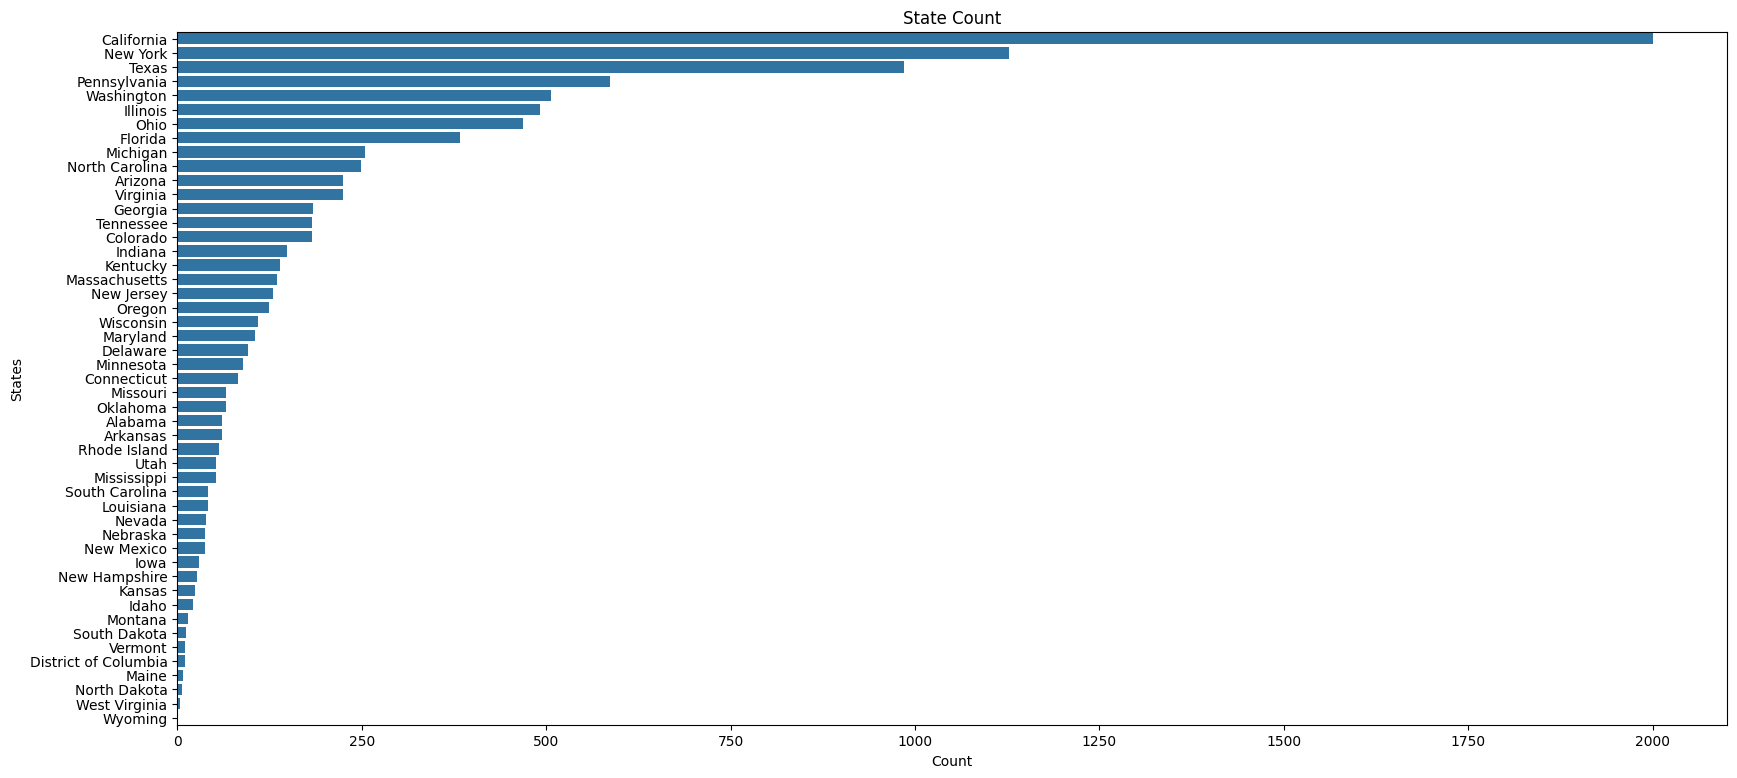

In [ ]:
#visual 1 - #starting with state visualization
state = df_super["State"].value_counts().to_frame().reset_index()
plt.figure(figsize = (20,9))
sns.barplot(y = state["State"], x = state["count"])
plt.ylabel("States")
plt.xlabel("Count")
plt.title("State Count");

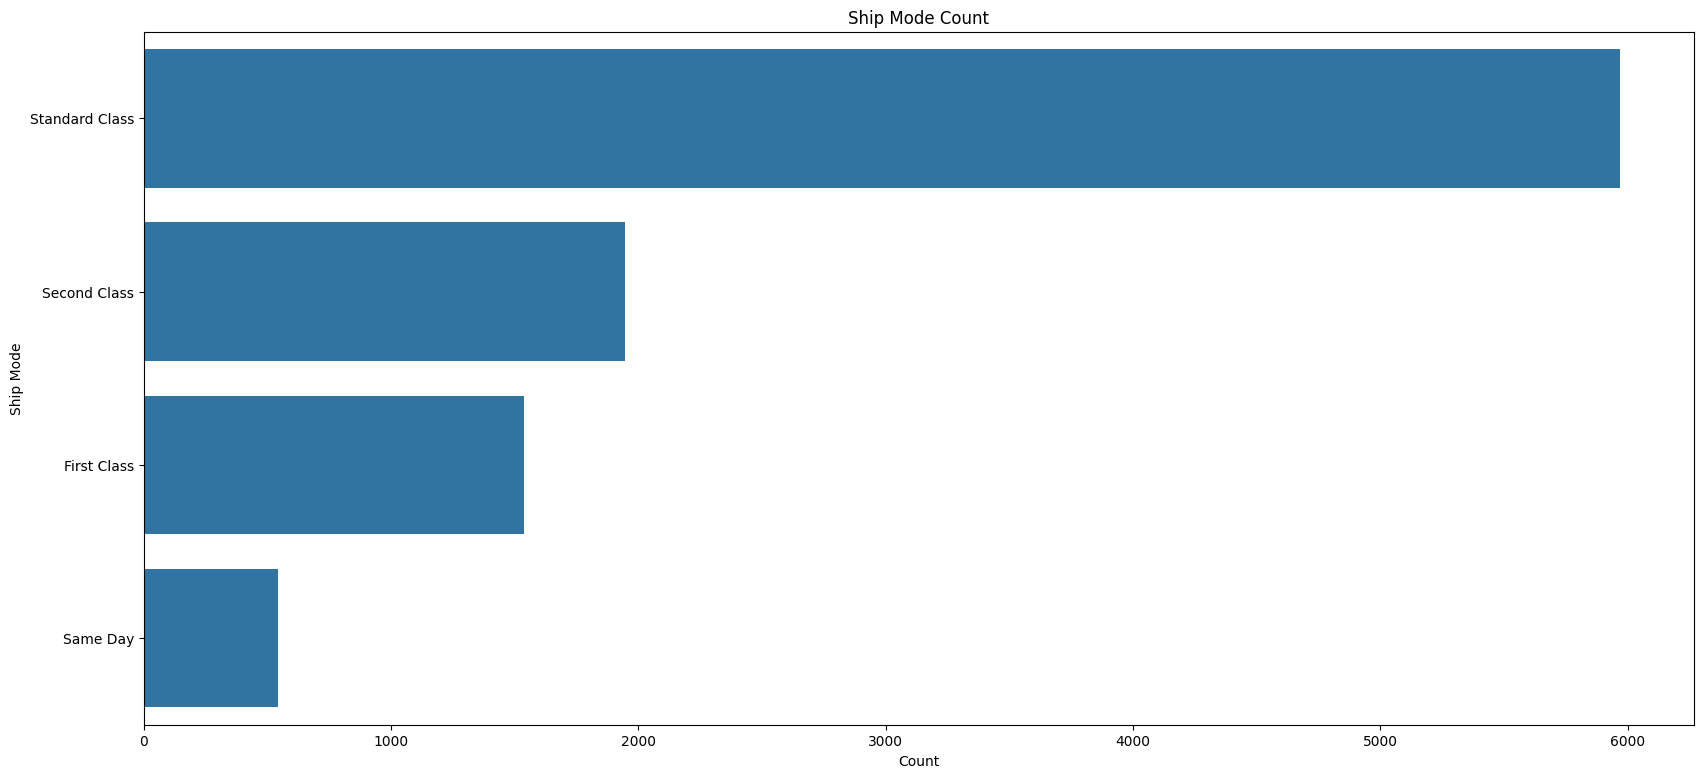

In [ ]:
#visualizations with ship mode
ship_mode = df_super["Ship Mode"].value_counts().to_frame().reset_index()
plt.figure(figsize = (20,9))
sns.barplot(y = ship_mode["Ship Mode"], x = ship_mode["count"])
plt.ylabel("Ship Mode")
plt.xlabel("Count")
plt.title("Ship Mode Count");
#

In [ ]:
#create a profit column
df_super['Profit'] = df_super['Sales'] - df_super['Profit']


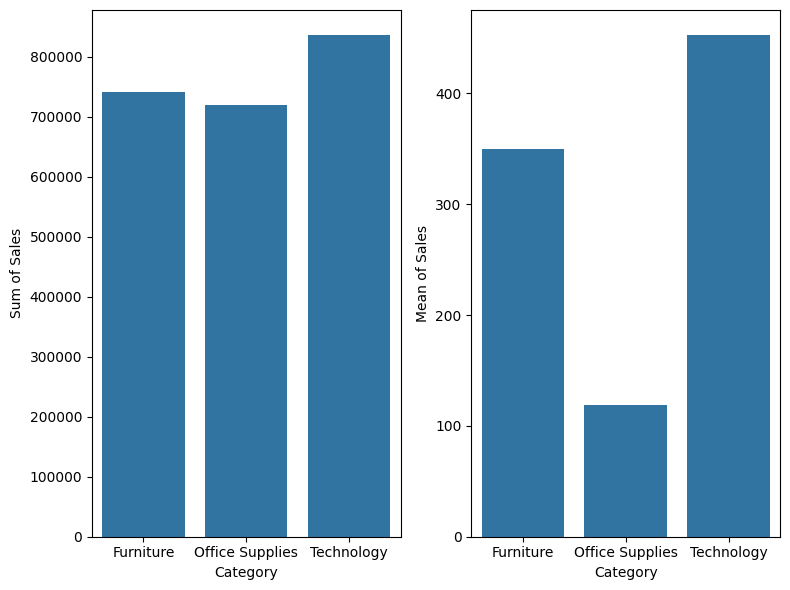

In [ ]:
#category visualizations
category = df_super.groupby("Category")[["Sales","Profit"]].agg(["sum", "mean"]).reset_index()
fig,ax = plt.subplots(1,2, figsize = (8,6))
ax1 = sns.barplot(x= category["Category"], y = category["Sales"]["sum"], ax=ax[0])
ax1.set_ylabel("Sum of Sales")
ax2 = sns.barplot(x = category["Category"], y = category["Sales"]["mean"], ax=ax[1])
ax2.set_ylabel("Mean of Sales")
plt.tight_layout();

/tmp/ipython-input-19746047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x = category["Category"], y= category["Profit"]["sum"], ax=ax[0],palette = "mako")
/tmp/ipython-input-19746047.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x = category["Category"], y = category["Profit"]["mean"], ax=ax[1],palette = "rocket")


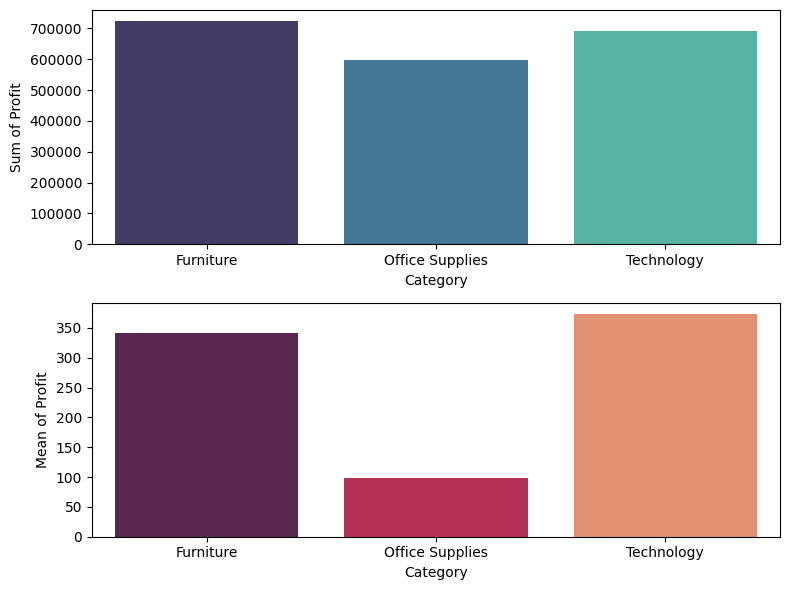

In [ ]:
fig, ax = plt.subplots(2, figsize = (8,6))
ax1 = sns.barplot(x = category["Category"], y= category["Profit"]["sum"], ax=ax[0],palette = "mako")
ax1.set_ylabel("Sum of Profit")
ax2 = sns.barplot(x = category["Category"], y = category["Profit"]["mean"], ax=ax[1],palette = "rocket")
ax2.set_ylabel("Mean of Profit")
plt.tight_layout();